--- DATASET LOADED ---
Features: 30
Samples: 569

Numerical Features: 30
Categorical Features: 0

--- PIPELINE CREATED ---
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['mean radius',
                                                   'mean texture',
                                                   'mean perimeter',
                                                   'mean area',
                                                   'mean smoothness',
                                                   'mean compactness',
                                                   'mean concavity',
                                                   'mean concave points',
                                                   'mean symmetry',
                                                   'mean fractal dimension',
                                                   'radius error',
       

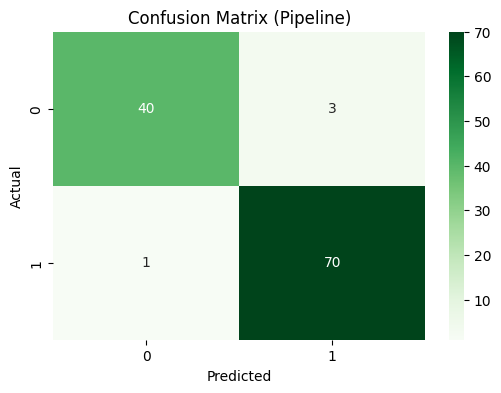


SUCCESS: End-to-End Pipeline saved as 'pipeline_model.pkl'


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# 1. Load Dataset (Primary: Sklearn Breast Cancer)
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("--- DATASET LOADED ---")
print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")

# 2. Separate Features
# In this specific dataset, all features are numerical.
# However, we will define the lists dynamically to show how to handle mixed data.
numeric_features = X.columns.tolist()
categorical_features = [] # No categorical features in this dataset, but we define the list for the pipeline structure.

print(f"\nNumerical Features: {len(numeric_features)}")
print(f"Categorical Features: {len(categorical_features)}")

# 3. Create Preprocessing Pipeline (ColumnTransformer)
# This is the "Magic" step. It bundles all preprocessing rules together.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        # If we had categorical data, we would add: ('cat', OneHotEncoder(), categorical_features)
    ]
)

# 4. Create the Full End-to-End Pipeline
# Step 1: Preprocessor (Scales data)
# Step 2: Classifier (Random Forest)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

print("\n--- PIPELINE CREATED ---")
print(pipeline)

# 5. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Train the Pipeline
# Notice we pass the RAW X_train. The pipeline handles scaling internally!
pipeline.fit(X_train, y_train)
print("\n--- PIPELINE TRAINED ---")

# 7. Evaluate
y_pred = pipeline.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix (Pipeline)")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 8. Save the Pipeline
# We save the WHOLE pipeline. When we load this later, it will remember exactly how to scale new data.
joblib.dump(pipeline, 'pipeline_model.pkl')
print("\nSUCCESS: End-to-End Pipeline saved as 'pipeline_model.pkl'")